# 用户指南，第28章：歌词搜索
[原文链接](https://www.music21.org/music21docs/usersGuide/usersGuide_28_lyricSearcher.html)

TODO

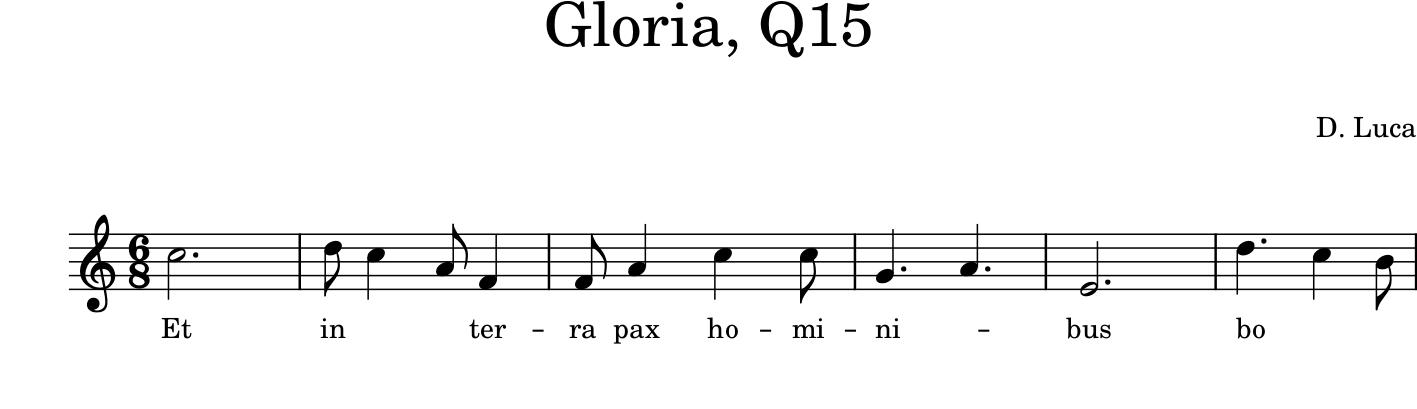

In [1]:
from music21 import *

luca = corpus.parse('luca/gloria')
cantus = luca.parts[0]
cantus.measures(1, 6).show()

In [2]:
dominePS = None
for n in cantus.recurse().getElementsByClass('Note'):
    if n.lyric == 'Domine':
        dominePS = n.pitch.ps

In [3]:
print(dominePS)

None


In [4]:
allText = text.assembleLyrics(cantus)
if 'Domine' in allText:
    print("Yup!")

Yup!


In [5]:
ls = search.lyrics.LyricSearcher(cantus)

In [6]:
domineResults = ls.search("Domine")

In [7]:
len(domineResults)

3

In [8]:
domineResults

[SearchMatch(mStart=28, mEnd=29, matchText='Domine', els=(<music21.note.Note C>, <music21.note.Note A>, <music21.note.Note F>), indices=[...], identifier=1),
 SearchMatch(mStart=38, mEnd=39, matchText='Domine', els=(<music21.note.Note C>, <music21.note.Note A>, <music21.note.Note B>), indices=[...], identifier=1),
 SearchMatch(mStart=48, mEnd=48, matchText='Domine', els=(<music21.note.Note A>, <music21.note.Note B>, <music21.note.Note C>), indices=[...], identifier=1)]

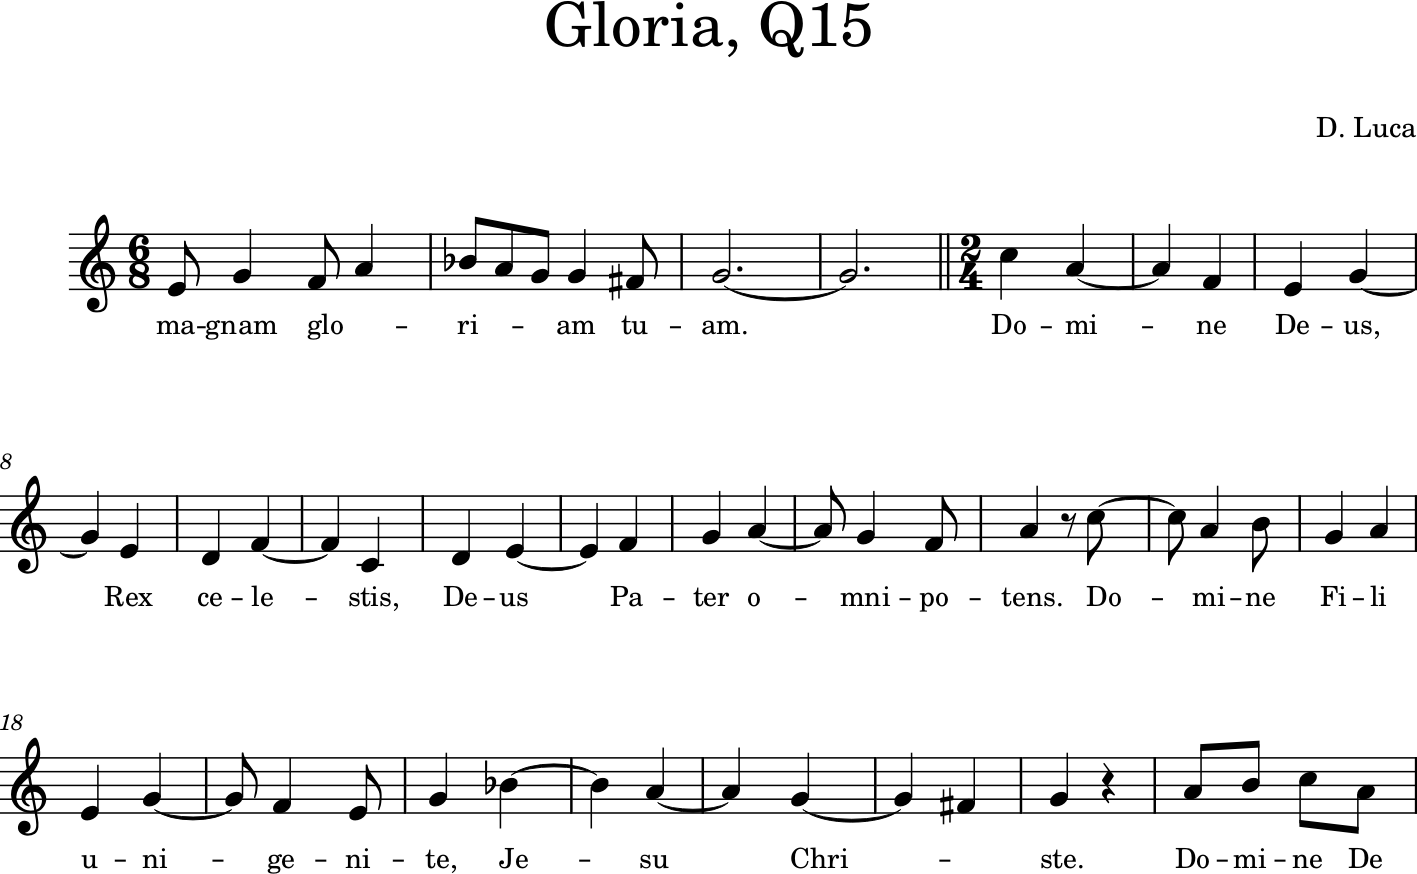

In [9]:
cantus.measures(24, 48).show()

In [10]:
sm0 = domineResults[0]
sm0.mStart, sm0.mEnd

(28, 29)

In [11]:
sm0.els

(<music21.note.Note C>, <music21.note.Note A>, <music21.note.Note F>)

In [12]:
smGloriam = ls.search('iam tuam.')
smGloriam[0].els

(<music21.note.Note B->,
 <music21.note.Note G>,
 <music21.note.Note F#>,
 <music21.note.Note G>)

In [13]:
firstNote = smGloriam[0].els[0]
lastNote = smGloriam[0].els[-1]

allRelevantNotes = [firstNote]
currentNote = firstNote

while currentNote is not None:
    currentNote = currentNote.next('Note')
    allRelevantNotes.append(currentNote)
    if currentNote is lastNote:
        break

allRelevantNotes

[<music21.note.Note B->,
 <music21.note.Note A>,
 <music21.note.Note G>,
 <music21.note.Note G>,
 <music21.note.Note F#>,
 <music21.note.Note G>]

In [14]:
sm0.matchText

'Domine'

In [15]:
import re
reSearchVowels = re.compile(r'\w+o\wi\w+', re.IGNORECASE)
foundVowels = ls.search(reSearchVowels)
len(foundVowels)

11

In [16]:
[result.matchText for result in foundVowels]

['hominibus',
 'Glorificamus',
 'gloriam',
 'Domine',
 'Domine',
 'Domine',
 'nobis',
 'nobis',
 'Quoniam',
 'Dominus',
 'gloria']

In [17]:
dominePitchPSes = []
for thisMatch in domineResults:
    for thisNote in thisMatch.els:
        dominePitchPSes.append(thisNote.pitch.ps)

dominePitchPSes

[72.0, 69.0, 65.0, 72.0, 69.0, 71.0, 69.0, 71.0, 72.0]

In [18]:
from statistics import mean, median

mean(dominePitchPSes), median(dominePitchPSes)

(70.0, 71.0)

In [19]:
allPitchPSes = []
for thisNote in cantus.recurse().notes:
    allPitchPSes.append(thisNote.pitch.ps)
    
mean(allPitchPSes), median(allPitchPSes)

(67.41100323624596, 67.0)